> **AI-generated.** An AI assistant drafted this page, and no maintainer has reviewed it yet. Please report errors on the issue tracker.

# Tutorial 2: Forecasting with uncertainty

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/tutorials/02_forecasting.ipynb)

[Tutorial 1](01_first_analysis.ipynb) fit a Ricker model with process noise to the moose counts of 1967 to 1988.
In this tutorial we forecast the population of 1989 to 1993 and ask where the forecast's uncertainty comes from.
Forecasting adds one idea: an ordinary Python function applied to a distribution gives the distribution of its output.

By the end of this tutorial you will have:

1. applied a function to the posterior to get the distribution of each year's population;
2. forecast the population five years ahead, with new process noise;
3. computed the probabilities of events, such as the population exceeding a threshold;
4. split the forecast's uncertainty into the part from the parameters and the part from the process noise.

The tutorial takes about 25 minutes, and it ends with three exercises.

In [1]:
# On Google Colab, install ProbPipe and download the data; elsewhere this cell does nothing.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    import urllib.request

    %pip install --quiet "probpipe-core @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/TARPS-group/prob-pipe/dev/overhaul/"
        "docs/tutorials/data/moose.csv",
        "data/moose.csv",
    )

In [2]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from probpipe import (
    Beta,
    HalfNormal,
    LogNormal,
    Normal,
    Poisson,
    condition_on,
    conditional_distribution,
    expectation,
    function,
    quantile,
    variance,
    workflow_run,
)

# TensorFlow Probability warns that JAX runs in 32-bit precision, which these models use.
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype float64")

## 1. The model of tutorial 1

This cell repeats tutorial 1's model with process noise and fits it to the counts.
Section 7 of tutorial 1 explains each part.

In [3]:
data = pd.read_csv("data/moose.csv")
years = data["year"].to_numpy()
counts = jnp.asarray(data["count"], dtype=jnp.float32)
YEARS = counts.shape[0]


def trajectory(r, K, n0, shocks):
    """The population in each year after the year of n0, given each year's shock to the growth."""

    def step(N, shock):
        N_next = N * jnp.exp(r * (1.0 - N / K) + shock)
        return N_next, N_next

    _, N = jax.lax.scan(step, jnp.asarray(n0, dtype=jnp.float32), shocks)
    return N


prior = (
    LogNormal("K", jnp.log(350.0), 0.4)
    * LogNormal("r", jnp.log(0.4), 0.4)
    * Beta("phi", 2.0, 2.0)
    * HalfNormal("sigma", 0.2)
    * Normal("shocks", jnp.zeros(YEARS), 1.0)
)


def ricker_counts(K, r, phi, sigma, shocks, n0=50.0):
    return Poisson("y", phi * trajectory(r, K, n0, sigma * shocks))


likelihood = conditional_distribution("counts", ricker_counts, given_spec=prior.event_spec.components)
with workflow_run(seed=4):
    posterior = condition_on(likelihood * prior, {"y": counts})
print("posterior:", posterior.label)
print("number of draws:", posterior.num_atoms)

posterior: counts·K·r·phi·sigma·shocks | y
number of draws: 4000


## 2. A function of the posterior

The population of each year is a function of the parameters: `trajectory` computes it from $r$, $K$, $\sigma$, and the shocks.
The decorator `@function` makes a Python function into a ProbPipe `Function`.
Called with numbers, a `Function` returns its value; called with distributions, it returns the distribution of its value.

In [4]:
@function
def population(K, r, sigma, shocks):
    return trajectory(r, K, 50.0, sigma * shocks)


print(
    "population at one set of values:",
    np.round(np.asarray(population(400.0, 0.3, 0.1, jnp.zeros(YEARS)))[:5], 1),
)

population at one set of values: [ 65.   83.6 106.  132.1 161.5]


Called with the posterior's parameters, the function is evaluated at the posterior's draws.
The four arguments are parameters of one posterior, so each evaluation reads them from the same draw, which keeps their dependence.

A function applied to distributions is evaluated at 256 draws by default.
`with_options(n_broadcast_samples=...)` sets the number, and with as many evaluations as the posterior has draws, the function is evaluated once at each.

distribution of the population: population
number of draws: 4000


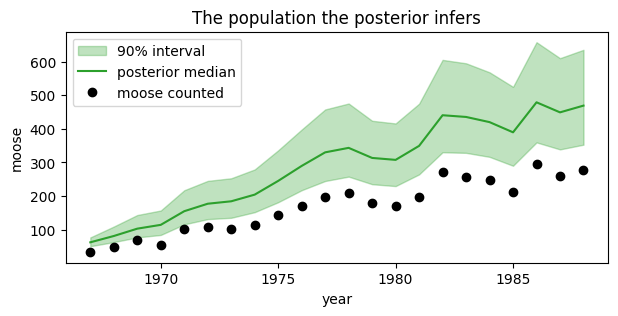

In [5]:
DRAWS = posterior.num_atoms
with workflow_run(seed=5):
    past_population = population.with_options(n_broadcast_samples=DRAWS)(
        posterior["K"], posterior["r"], posterior["sigma"], posterior["shocks"]
    )
print("distribution of the population:", past_population.label)
print("number of draws:", past_population.num_atoms)

bands = np.asarray(quantile(past_population, jnp.array([0.05, 0.5, 0.95])).values)
fig, ax = plt.subplots(figsize=(7, 3))
ax.fill_between(years, bands[0], bands[2], color="tab:green", alpha=0.3, label="90% interval")
ax.plot(years, bands[1], color="tab:green", label="posterior median")
ax.plot(years, counts, "o", color="black", label="moose counted")
ax.set(xlabel="year", ylabel="moose", title="The population the posterior infers")
ax.legend()
plt.show()

The population lies above the counts, since a survey finds each animal with probability $\phi$, whose posterior mean is near 0.6.

## 3. Forecasting five years

A forecast continues the recursion past 1988.
The parameters come from the posterior, and the shocks of the future years are new: they follow the prior $z_t \sim \text{Normal}(0, 1)$, since no count has informed them.
`forecast_population` takes both and returns the population of 1989 to 1993.

In [6]:
HORIZON = 5
future_years = np.arange(years[-1] + 1, years[-1] + 1 + HORIZON)
future_shocks = Normal("future_shocks", jnp.zeros(HORIZON), 1.0)


@function
def forecast_population(K, r, sigma, shocks, future_shocks):
    past = trajectory(r, K, 50.0, sigma * shocks)
    return trajectory(r, K, past[-1], sigma * future_shocks)


with workflow_run(seed=6):
    forecast = forecast_population.with_options(n_broadcast_samples=DRAWS)(
        posterior["K"], posterior["r"], posterior["sigma"], posterior["shocks"], future_shocks
    )
print("distribution of the forecast:", forecast.label)

distribution of the forecast: forecast_population


`future_shocks` is independent of the posterior, so each evaluation pairs one draw of the posterior with a new draw of the future shocks.
The forecast's quantiles give a fan chart: the band widens with the horizon.

1989: median 454 moose, 90% interval (325, 656)
1990: median 449 moose, 90% interval (306, 658)
1991: median 441 moose, 90% interval (297, 664)
1992: median 438 moose, 90% interval (288, 668)
1993: median 437 moose, 90% interval (283, 672)


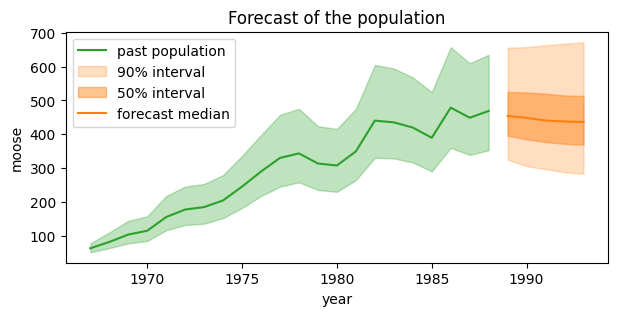

In [7]:
levels = jnp.array([0.05, 0.25, 0.5, 0.75, 0.95])
fan = np.asarray(quantile(forecast, levels).values)
for year, low, median, high in zip(future_years, fan[0], fan[2], fan[4]):
    print(f"{year}: median {median:.0f} moose, 90% interval ({low:.0f}, {high:.0f})")

fig, ax = plt.subplots(figsize=(7, 3))
ax.fill_between(years, bands[0], bands[2], color="tab:green", alpha=0.3)
ax.plot(years, bands[1], color="tab:green", label="past population")
ax.fill_between(future_years, fan[0], fan[4], color="tab:orange", alpha=0.25, label="90% interval")
ax.fill_between(future_years, fan[1], fan[3], color="tab:orange", alpha=0.45, label="50% interval")
ax.plot(future_years, fan[2], color="tab:orange", label="forecast median")
ax.set(xlabel="year", ylabel="moose", title="Forecast of the population")
ax.legend(loc="upper left")
plt.show()

## 4. Probabilities of events

A manager may ask how likely an event is, such as the population exceeding 500 animals in 1993.
The probability of an event is the expectation of its indicator, which `expectation` computes for a distribution and a function of its value.

In [8]:
above_500 = expectation(forecast, lambda N: (N[-1] > 500.0).astype(jnp.float32))
below_300 = expectation(forecast, lambda N: (N[-1] < 300.0).astype(jnp.float32))
print("probability that the 1993 population exceeds 500:", round(float(above_500), 3))
print("probability that the 1993 population is below 300:", round(float(below_300), 3))

probability that the 1993 population exceeds 500: 0.286
probability that the 1993 population is below 300: 0.075


## 5. Where the uncertainty comes from

The forecast is uncertain for two reasons: the parameters are uncertain, and the future shocks are random.
Fixing the future shocks at zero removes the second reason, and the variance of that forecast approximates the part due to the parameters, including the past shocks that set the population of 1988.
The rest of the total variance approximates the part due to the future shocks.
This split of a forecast's variance guides what to do next: more data narrow the first part, and nothing narrows the second.

1989: share of the forecast's variance due to the parameters 0.63
1990: share of the forecast's variance due to the parameters 0.54
1991: share of the forecast's variance due to the parameters 0.50
1992: share of the forecast's variance due to the parameters 0.50
1993: share of the forecast's variance due to the parameters 0.49


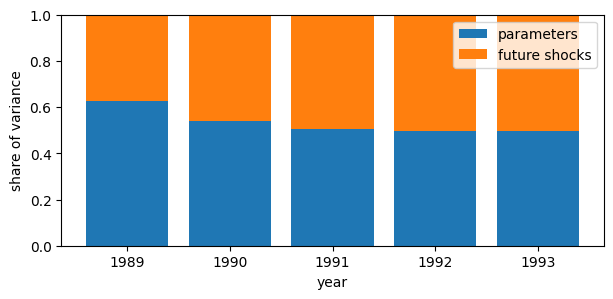

In [9]:
with workflow_run(seed=7):
    parameters_only = forecast_population.with_options(n_broadcast_samples=DRAWS)(
        posterior["K"], posterior["r"], posterior["sigma"], posterior["shocks"], jnp.zeros(HORIZON)
    )
total_variance = np.asarray(variance(forecast))
parameter_variance = np.asarray(variance(parameters_only))
share = parameter_variance / total_variance
for year, fraction in zip(future_years, share):
    print(f"{year}: share of the forecast's variance due to the parameters {fraction:.2f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(future_years, share, color="tab:blue", label="parameters")
ax.bar(future_years, 1.0 - share, bottom=share, color="tab:orange", label="future shocks")
ax.set(xlabel="year", ylabel="share of variance", ylim=(0, 1))
ax.legend()
plt.show()

The parameters' share falls over the first years, since each year adds a new shock, and it levels off near one half, since the density dependence pulls the population back toward $K$.

## 6. Exercises

Each exercise is followed by a solution, which Colab shows collapsed.

**Exercise 1.** Forecast ten years ahead, to 1998, and report the median and 90% interval of the population of 1998.

In [10]:
# @title Solution
ten_year_shocks = Normal("future_shocks", jnp.zeros(10), 1.0)
with workflow_run(seed=8):
    ten_years = forecast_population.with_options(n_broadcast_samples=DRAWS)(
        posterior["K"], posterior["r"], posterior["sigma"], posterior["shocks"], ten_year_shocks
    )
low, median, high = np.asarray(quantile(ten_years, jnp.array([0.05, 0.5, 0.95])).values)[:, -1]
print(f"1998: median {median:.0f} moose, 90% interval ({low:.0f}, {high:.0f})")

1998: median 430 moose, 90% interval (271, 667)


**Exercise 2.** What is the probability that the population of 1993 is smaller than that of 1988?
The forecast holds only the years after 1988, so write a function that returns the change from 1988 to 1993, and take the expectation of its indicator.

In [11]:
# @title Solution
@function
def change_to_1993(K, r, sigma, shocks, future_shocks):
    past = trajectory(r, K, 50.0, sigma * shocks)
    future = trajectory(r, K, past[-1], sigma * future_shocks)
    return future[-1] - past[-1]


with workflow_run(seed=9):
    change = change_to_1993.with_options(n_broadcast_samples=DRAWS)(
        posterior["K"], posterior["r"], posterior["sigma"], posterior["shocks"], future_shocks
    )
decline = expectation(change, lambda c: (c < 0.0).astype(jnp.float32))
print("probability that the population is smaller in 1993 than in 1988:", round(float(decline), 3))

probability that the population is smaller in 1993 than in 1988: 0.647


**Exercise 3.** A survey finds a fraction $\phi$ of the population, so the count it expects is $\phi N_t$.
Forecast the expected count of each year from 1989 to 1993, and report the medians.

In [12]:
# @title Solution
@function
def expected_count(K, r, phi, sigma, shocks, future_shocks):
    past = trajectory(r, K, 50.0, sigma * shocks)
    return phi * trajectory(r, K, past[-1], sigma * future_shocks)


with workflow_run(seed=10):
    expected = expected_count.with_options(n_broadcast_samples=DRAWS)(
        posterior["K"],
        posterior["r"],
        posterior["phi"],
        posterior["sigma"],
        posterior["shocks"],
        future_shocks,
    )
medians = np.asarray(quantile(expected, jnp.array([0.5])).values)[0]
for year, median in zip(future_years, medians):
    print(f"{year}: median expected count {median:.0f}")

1989: median expected count 266
1990: median expected count 263
1991: median expected count 258
1992: median expected count 254
1993: median expected count 253


## Summary

- `@function` makes a Python function into a `Function`, which applied to distributions returns the distribution of its value.
- Parameters of one posterior are read from the same draw, and an independent distribution, such as the future shocks, is drawn separately.
- `quantile` gives forecast intervals, and `expectation` gives the probabilities of events.
- Comparing the forecast with and without future shocks splits its variance into the parts due to the parameters and to the process noise.

[Tutorial 3](03_updating.ipynb) updates the forecasts as each year's count arrives.

## References

- Dietze, M. C. (2017). *Ecological Forecasting*. Princeton University Press. It partitions a forecast's uncertainty into its sources.